<a href="https://colab.research.google.com/github/mvharsh/Mathematical-Computing/blob/main/Graphical_Method_LPP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SOLVING LINEAR PROGRAMMING PROBLEM (LPP) USING GRAPHICAL METHOD**

**AIM:**

Solving a Linear Programming Problem (LPP) Using the Graphical Method and Visualizing the Feasible Region and Optimal Solution


**ALGORITHM:**

1.	Define the Objective Function:

  o	Input the coefficients of the objective function Z=c1x1+c2x2
  
2.	Input the Constraints:

  o	Enter the number of constraints.

  o	For each constraint, input coefficients a1, a2 and the constant b in the form a1x1+a2x2≤b.
3.	Solve the Problem:

  o	Calculate the intersection points of the constraints to identify vertices of the feasible region.

  o	Use the objective function to evaluate Z at each vertex to find the optimal solution.
4.	Graphical Visualization:

  o	Plot each constraint line.

  o	Shade the feasible region.

  o	Highlight intersection points of the constraints and label them as A(), B(), C() etc.

  o	Mark the optimal solution point and annotate it on the graph.
5.	Output Results:

  o	Print the optimal values of x1, x2, and Z

  o	Display the graph with constraints, feasible region, and solution points.


Enter coefficients of Z (c1, c2) separated by space: 8 1
Enter the number of constraints: 2
Constraint 1: Enter a1, a2, b (separated by space): 1 1 40
Constraint 2: Enter a1, a2, b (separated by space): 2 1 60
Optimal Solution: x1 = 30.00, x2 = 0.00, Z = 240.00


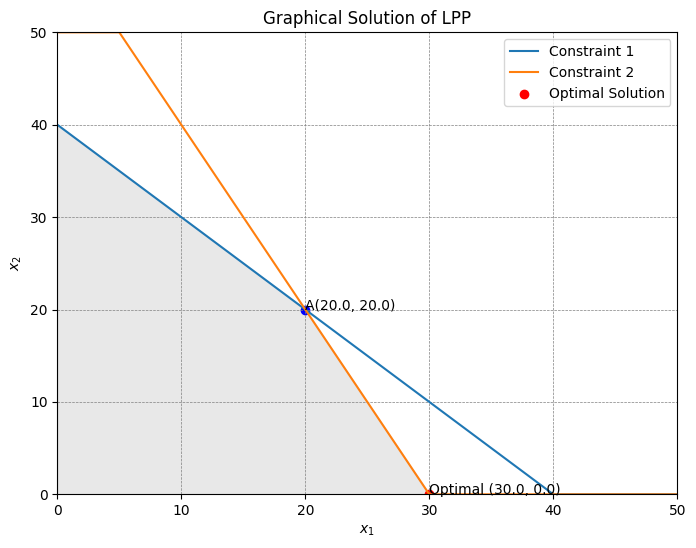

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from itertools import combinations

# Function to get user inputs
def get_inputs():
    c = list(map(float, input("Enter coefficients of Z (c1, c2) separated by space: ").split()))
    n = int(input("Enter the number of constraints: "))
    A, b = [], []
    for i in range(n):
        print(f"Constraint {i+1}: Enter a1, a2, b (separated by space): ", end="")
        *a, b_val = map(float, input().split())
        A.append(a)
        b.append(b_val)
    return [-c[0], -c[1]], np.array(A), np.array(b)

# Function to find intersection points
def find_intersections(A, b):
    points = []
    for i, j in combinations(range(len(A)), 2):
        A_ij, b_ij = np.array([A[i], A[j]]), np.array([b[i], b[j]])
        if np.linalg.det(A_ij) != 0:  # Ensure not parallel
            point = np.linalg.solve(A_ij, b_ij)
            if np.all(point >= 0):  # Only points in the first quadrant
                points.append(tuple(point))
    return points

# Function to plot the graph
def plot_graph(c, A, b, result):
    x = np.linspace(0, 50, 500)
    plt.figure(figsize=(8, 6))

    # Plot constraints and feasible region
    for i, (a, b_val) in enumerate(zip(A, b)):
        y = np.clip((b_val - a[0] * x) / (a[1] if a[1] != 0 else np.inf), 0, 50)
        plt.plot(x, y, label=f"Constraint {i+1}")

    # Highlight feasible region
    feasible_y = np.minimum.reduce([
        np.clip((b[i] - A[i][0] * x) / (A[i][1] if A[i][1] != 0 else np.inf), 0, 50)
        for i in range(len(A))
    ])
    plt.fill_between(x, feasible_y, color="lightgrey", alpha=0.5)

    # Plot intersection points
    points = find_intersections(A, b)
    for i, (px, py) in enumerate(points):
        plt.scatter(px, py, color="blue")
        plt.text(px, py, f"{chr(65 + i)}({px:.1f}, {py:.1f})", fontsize=10)

    # Mark the optimal solution
    if result.success:
        plt.scatter(result.x[0], result.x[1], color="red", label="Optimal Solution")
        plt.text(result.x[0], result.x[1], f"Optimal ({result.x[0]:.1f}, {result.x[1]:.1f})", fontsize=10)

    # Set graph details
    plt.xlim(0, 50)
    plt.ylim(0, 50)
    plt.axhline(0, color="black", linewidth=0.5)
    plt.axvline(0, color="black", linewidth=0.5)
    plt.grid(color="gray", linestyle="--", linewidth=0.5)
    plt.legend()
    plt.title("Graphical Solution of LPP")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.show()

# Main function
def main():
    c, A, b = get_inputs()
    result = linprog(c, A_ub=A, b_ub=b, method="highs")
    if result.success:
        print(f"Optimal Solution: x1 = {result.x[0]:.2f}, x2 = {result.x[1]:.2f}, Z = {-result.fun:.2f}")
    else:
        print("No feasible solution found.")
    plot_graph(c, A, b, result)

if __name__ == "__main__":
    main()
